# Предсказание возраста посетителей сайтов по данным о поведении анонимных пользователей в цифровой среде

- Автор: Попов Егор
- Дата: 25.03.2026

### Цель проекта

Построить модель машинного обучения, которая по данным о поведении анонимного пользователя в цифровой среде будет определять его примерный возраст. По итогам исследования необходимо выбрать наилучшую модель по ключевой метрике `F1-мера` и сохранить весь пайплайн предобработки данных и саму модель для внедрения в продакшен.

### Постановка задачи машинного обучения
- **Задача машинного обучения**: ввиду того, что целевая переменная `age_category` (возрастная группа пользователя) является категориальной, а предсказания планируется делать на основе уже имеющихся сведений о возрастной группе в зависимости от поведения пользователей перед нами стоит задача обучения с учителем, а конкретно - мультиклассовая классификация.
- **Целевая переменная**: категориальная величина `age_category` - возрастная категория пользователя.
- **Метрики качества**: основной метрикой качества является `F1-marco`. В качестве вспомогательных метрик, оценивающих качество модели, будут использоваться `presicion-marco`, `recall-marco`.
- **Критерии успешности проекта**: значение метрики `F1-marco` для лучшей модели не менее 0.75.

## Содержимое проекта

<a id="toc"></a>
- [1. Подготовка среды и библиотек](#подготовка-среды-и-библиотек)
- [2. Загрузка данных и знакомство с ними](#загрузка-данных-и-знакомство-с-ними)
- [3. Сведение данных в единый датафрейм](#сведение-данных-в-единый-датафрейм)
- [4. Исследовательский анализ данных](#исследовательский-анализ-данных)
- [5. Предобработка данных](#предобработка-данных)
- [6. Обучение и оценка базовой модели](#обучение-и-оценка-базовой-модели)
- [7. Создание и отбор признаков](#создание-и-отбор-признаков)
- [8. Подбор гиперпараметров моделей](#подбор-гиперпараметров-моделей)
- [9. Оценка финальной модели](#оценка-финальной-модели)
- [10. Подготовка артефактов модели для внедрения](#подготовка-артефактов-модели-для-внедрения)
- [11. Выводы о результатах работы](#выводы-о-результатах-работы)

<a id="подготовка-среды-и-библиотек"></a>
## Подготовка среды и библиотек

Зафиксируем версии пакетов в файле `requirements.txt`, который можно посмотреть по ссылке на GitHub проекта: https://github.com/KeshaTrappy/project-module-3. Также прилагаю список библиотек локально.

asttokens==3.0.1
category_encoders==2.9.0
colorama==0.4.6
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.20
decorator==5.2.1
executing==2.2.1
fonttools==4.61.1
ipykernel==7.1.0
ipython==9.9.0
ipython_pygments_lexers==1.1.1
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.3
jupyter_client==8.8.0
jupyter_core==5.9.1
kiwisolver==1.4.9
MarkupSafe==3.0.3
matplotlib==3.10.8
matplotlib-inline==0.2.1
nest-asyncio==1.6.0
numpy==2.4.2
packaging==26.0
pandas==2.2.3
parso==0.8.5
patsy==1.0.2
phik==0.12.5
pillow==12.1.0
platformdirs==4.5.1
prompt_toolkit==3.0.52
psutil==7.2.2
pure_eval==0.2.3
Pygments==2.19.2
pyparsing==3.3.2
python-dateutil==2.9.0.post0
pytz==2025.2
pyzmq==27.1.0
scikit-learn==1.7.0
scipy==1.17.0
seaborn==0.13.2
six==1.17.0
stack-data==0.6.3
statsmodels==0.14.6
threadpoolctl==3.6.0
tornado==6.5.4
traitlets==5.14.3
tzdata==2025.3
wcwidth==0.5.3


Импортируем библиотеки, которые будут использоваться в проекте.

In [1]:
# Для работы с матрицами признаков, вектора весов и целевой переменной
import numpy as np

# Для работы с исходным датафреймом с данными от TurtleCV
import pandas as pd

# Импортируем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Импортируем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

# Импортируем библиотеку для отслеживания длительности обучения
from time import time

# Игнорируем предупреждения
import warnings
warnings.filterwarnings("ignore")

# Для обращения к переменным среды
import os

# Импортируем модули для построения модели
from sklearn.model_selection import (train_test_split,
                                     cross_validate,
                                     StratifiedKFold,
                                     GridSearchCV)

from sklearn.preprocessing import (OneHotEncoder, 
                                   StandardScaler,
                                   FunctionTransformer)

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.feature_selection import (VarianceThreshold,
                                       SequentialFeatureSelector)

from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

from sklearn.metrics import (precision_score,
                             recall_score,
                             f1_score,
                             accuracy_score,
                             classification_report,
                             confusion_matrix)

from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.base import BaseEstimator, TransformerMixin

# Загрузка модели
import joblib

Настроим параметры отображения графиков и датафреймов.

In [2]:
def setup_df_plot_settings():
  
    # Pandas
    pd.set_option('display.max_rows', 50)
    pd.set_option('display.max_columns', 50)
    pd.set_option('display.width', 1000)
    pd.set_option('display.float_format', '{:.3f}'.format)
    
    # Matplotlib
    plt.rcParams['figure.figsize'] = (14, 7)
    plt.rcParams['figure.dpi'] = 100
    plt.rcParams['font.size'] = 11
    
    # Seaborn
    sns.set_style('whitegrid')
    sns.set_context('paper')
    
    print("Настройки применены успешно!")

setup_df_plot_settings()

Настройки применены успешно!


Зафиксируем константу для воспроизводимости результатов.

In [3]:
# Для воспроизводимости фиксируем random_seed
RANDOM_SEED=42

[Назад к оглавлению](#toc)

<a id="загрузка-данных-и-знакомство-с-ними"></a>
## Загрузка данных и знакомство с ними

Данные представлены в нескольких CSV-файлах, поэтому последовательно загрузим каждый CSV в отдельный датафрейм и проанализируем доступные признаки.

In [4]:
# Записываем все CSV в отдельные датафреймы
try:
    users_df = pd.read_csv('/datasets/ds_s13_users.csv')
    visits_df = pd.read_csv('/datasets/ds_s13_visits.csv')
    ads_activity_df = pd.read_csv('/datasets/ads_activity.csv')
    surf_depth_df = pd.read_csv('/datasets/surf_depth.csv')
    primary_device_df = pd.read_csv('/datasets/primary_device.csv')
    cloud_usage_df = pd.read_csv('/datasets/cloud_usage.csv')
except:
    users_df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_users.csv')
    visits_df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_visits.csv')
    ads_activity_df = pd.read_csv('https://code.s3.yandex.net/datasets/ads_activity.csv')
    surf_depth_df = pd.read_csv('https://code.s3.yandex.net/datasets/surf_depth.csv')
    primary_device_df = pd.read_csv('https://code.s3.yandex.net/datasets/primary_device.csv')
    cloud_usage_df = pd.read_csv('https://code.s3.yandex.net/datasets/cloud_usage.csv')    


**Датафрейм `users_df`** содержит информацию о возрастной категории пользователя.

In [5]:
# Выведем информацию о датафреймe users_df
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB


In [6]:
# Выведем информацию несколько первых строк
users_df.head()

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


In [7]:
# Проверим все ли строки датафрейма описывают уникальных пользователей
if users_df['user_id'].duplicated().sum() == 0:
    print('Все строки содержат уникальный id пользователя')
else:    
    print('Кол-во дублирующихся id пользователя:', users_df['user_id'].duplicated().sum())

Кол-во дублирующихся id пользователя: 87


Описание столбцов `users_df`:
- `user_id` - уникальный идентификатор пользователя;
- `age_category` - возрастная категория пользователя (целевая переменная). Содержит следующие категории:
    - `0`: младше 18;
    - `1`: 18-25 лет;
    - `2`: 26-40 лет;
    - `3`: 41-55 лет;
    - `4`: 56+ лет.

Датафрейм `users_df` содержит 5913 строки и 2 столбца. Названия столбцов приведены к snake_case и по смыслу соответствуют, содержащимся в них данным. Пропусков в датафрейме не обнаружено. Существуют строки с повторяющимися id пользователей.

**Датафрейм `visits_df`** содержит информацию об активности пользователей разных сайтов.

In [8]:
# Выведем информацию о датафреймe visits_df
visits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB


In [9]:
# Выведем информацию несколько первых строк
visits_df.head()

,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


In [10]:
# Проверим все ли строки датафрейма описывают уникальных пользователей
if visits_df['user_id'].duplicated().sum() == 0:
    print('Все строки содержат уникальный id пользователя')
else:    
    print('Кол-во дублирующихся id пользователя:', visits_df['user_id'].duplicated().sum())

Кол-во дублирующихся id пользователя: 1059919


Описание столбцов `visits_df`:
- `date` - дата посещения сайта;
- `daytime` - анонимизированное время посещения сайта. Категории: утро, день, вечер, ночь;
- `session_id` - уникальный идентификатор сессии;
- `user_id` - уникальный идентификатор пользователя;
- `website_category` - анонимизированная категория сайта.

Датафрейм `visits_df` содержит 1065745 строк и 5 столбцов. Названия столбцов приведены к snake_case и по смыслу соответствуют, содержащимся в них данным. Пропусков в датафрейме не обнаружено. Существуют строки с повторяющимися id пользователей.

**Датафрейм `ads_activity_df`** содержит информацию об активности взаимодействия пользователя с рекламными объявлениями.

In [11]:
# Выведем информацию о датафреймe ads_activity_df
ads_activity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   ads_activity  5826 non-null   object
dtypes: object(2)
memory usage: 91.2+ KB


In [12]:
# Выведем информацию несколько первых строк
ads_activity_df.head()

,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно


In [13]:
# Проверим все ли строки датафрейма описывают уникальных пользователей
if ads_activity_df['user_id'].duplicated().sum() == 0:
    print('Все строки содержат уникальный id пользователя')
else:    
    print('Кол-во дублирующихся id пользователя:', ads_activity_df['user_id'].duplicated().sum())

Кол-во дублирующихся id пользователя: 233


Описание столбцов `ads_activity_df`:
- `user_id` - уникальный идентификатор пользователя;
- `ads_activity` - характеристика CTR, выраженная одним из значений: очень редко, редко, умеренно, часто, очень часто.

Датафрейм `ads_activity_df` содержит 5826 строк и 2 столбца. Названия столбцов приведены к snake_case и по смыслу соответствуют, содержащимся в них данным. Пропусков в датафрейме не обнаружено.

**Датафрейм `surf_depth_df`**

In [14]:
# Выведем информацию о датафреймe surf_depth_df
surf_depth_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB


In [15]:
# Выведем информацию несколько первых строк
surf_depth_df.head()

,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко


In [16]:
# Проверим все ли строки датафрейма описывают уникальных пользователей
if surf_depth_df['user_id'].duplicated().sum() == 0:
    print('Все строки содержат уникальный id пользователя')
else:    
    print('Кол-во дублирующихся id пользователя:', surf_depth_df['user_id'].duplicated().sum())

Все строки содержат уникальный id пользователя


Описание столбцов `surf_depth_df`:
- `user_id` - уникальный идентификатор пользователя.
- `surf_depth` - категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории поверхностно, средне, глубоко.

Датафрейм `surf_depth_df` содержит 5715 строк и 2 столбца. Названия столбцов приведены к snake_case и по смыслу соответствуют, содержащимся в них данным. Пропусков в датафрейме не обнаружено. Все строки содержат уникальный id пользователя.

**Датафрейм `primary_device_df`**

In [17]:
# Выведем информацию о датафреймe primary_device_df
primary_device_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB


In [18]:
# Выведем информацию несколько первых строк
primary_device_df.head()

,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК


Описание столбцов `primary_device_df`:
- `user_id` - уникальный идентификатор пользователя;
- `primary_device` - информация о типе основного устройства пользователя для выхода в Интернет.

In [19]:
# Проверим все ли строки датафрейма описывают уникальных пользователей
if primary_device_df['user_id'].duplicated().sum() == 0:
    print('Все строки содержат уникальный id пользователя')
else:    
    print('Кол-во дублирующихся id пользователя:', primary_device_df['user_id'].duplicated().sum())

Все строки содержат уникальный id пользователя


Датафрейм `primary_device_df` содержит 5669 строк и 2 столбца. Названия столбцов приведены к snake_case и по смыслу соответствуют, содержащимся в них данным. Пропусков в датафрейме не обнаружено. Все строки содержат уникальный id пользователя.

**Датафрейм `cloud_usage_df`**

In [20]:
# Выведем информацию о датафреймe surf_depth_df
cloud_usage_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.1+ KB


In [21]:
# Выведем информацию несколько первых строк
cloud_usage_df.head()

,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


In [22]:
# Проверим все ли строки датафрейма описывают уникальных пользователей
if cloud_usage_df['user_id'].duplicated().sum() == 0:
    print('Все строки содержат уникальный id пользователя')
else:    
    print('Кол-во дублирующихся id пользователя:', cloud_usage_df['user_id'].duplicated().sum())

Все строки содержат уникальный id пользователя


**Описание столбцов `cloud_usage_df`**:
- `user_id` - уникальный идентификатор пользователя;
- `cloud_usage` - True означает, что пользователь обращается к облачным ресурсам типа Яндекс 360 прямо или через посещаемые сайты. Все строки содержат уникальный id пользователя.

Датафрейм `cloud_usage_df` содержит 5680 строк и 2 столбца. Названия столбцов приведены к snake_case и по смыслу соответствуют, содержащимся в них данным. Пропусков в датафрейме не обнаружено. Все строки содержат уникальный id пользователя.

**Промежуточный вывод**: Представленные датафреймы наглядно отражают представленную в них информацию и не содержат пропусков, однако в некоторых из них присутствуют повторяющиеся id пользователей. В частности выделяется `visits_df`, где количество строк превышает значение 1 млн. На этапе предобработки необходимо агрегировать данные и построить признаки, характеризующие предпочтения пользователей.

[Назад к оглавлению](#toc)

<a id="сведение-данных-в-единый-датафрейм"></a>
## Сведение данных в единый датафрейм

Проверим наличие в таблицах явных дубликатов.

In [23]:
# Создадим словарь с датафреймами
df_dict = {
    'users_df': users_df,
    'visits_df': visits_df,
    'ads_activity_df': ads_activity_df,
    'surf_depth_df': surf_depth_df,
    'primary_device_df': primary_device_df,
    'cloud_usage_df': cloud_usage_df
}

# Проверим таблицы на наличие явных дубликатов
for df_name, df in df_dict.items():
    if df.duplicated().sum() > 0:
        print(f"Кол-во явных дубликатов в {df_name}: {df.duplicated().sum()} шт.")
    else:
        print(f"В {df_name} нет явных дубликатов")

Кол-во явных дубликатов в users_df: 87 шт.
Кол-во явных дубликатов в visits_df: 15750 шт.
Кол-во явных дубликатов в ads_activity_df: 233 шт.
В surf_depth_df нет явных дубликатов
В primary_device_df нет явных дубликатов
В cloud_usage_df нет явных дубликатов


В таблицах `users_df`, `visits_df` и `ads_activity_df` присутствуют явные дубликаты. Возможно это обусловлено тем, что событие "задвоилось" в базе данных. Такие строки необходимо перед удалить перед агрегацией `visits_df` и объединением всех таблиц.

Также необходимо проверить все таблицы (кроме `visits_df` т.к. она содержит неагрегированные данные) на наличие неявных дубликатов. В данном случае неявными будут являться те строки, в которых дублируются строки `user_id`.

In [24]:
# Проверим таблицы на наличие неявных дубликатов
for df_name, df in df_dict.items():
    if df_name != 'visits_df':     
        if df['user_id'].duplicated().sum() - df.duplicated().sum() > 0:
            print(f"Кол-во неявных дубликатов в {df_name}: {df.duplicated().sum() - df['user_id'].duplicated().sum()} шт.")
        else:
            print(f"В {df_name} нет неявных дубликатов")

В users_df нет неявных дубликатов
В ads_activity_df нет неявных дубликатов
В surf_depth_df нет неявных дубликатов
В primary_device_df нет неявных дубликатов
В cloud_usage_df нет неявных дубликатов


Неявных дубликатов в таблицах не обнаружено.

По логу посещения сайтов построим признаки, характеризующие предпочтения пользователей. По данным всех сессий с помощью групповых операций рассчитаем, какая доля интернет-активности пользователя приходится на посещение сайтов разных категорий. Также создадим признаки на основе распределения активности пользователя по времени суток.

In [25]:
# Расчет количества сессий по категориям для каждого пользователя
session_per_category = pd.pivot_table(visits_df,
                              index='user_id',
                              columns='website_category',
                              values='session_id',
                              aggfunc='nunique',
                              fill_value=0)

# Убираем отображение имени колонок в pivot
session_per_category.columns.name = None

# Расчет количества сессий для каждого пользователя
sesions_per_user = visits_df.groupby('user_id')['session_id'].nunique()

# Перевод в относительные значения
session_per_category = session_per_category.div(sesions_per_user, axis='index')

# Сбрасываем индекс
session_per_category = session_per_category.reset_index()

# Выведем несколько строк
session_per_category.head()

,user_id,Category 01,Category 02,Category 03,Category 04,Category 05,Category 06,Category 07,Category 08,Category 09,Category 10,Category 11,Category 12,Category 13,Category 14,Category 15,Category 16,Category 17,Category 18,Category 19,Category 20
0,0010-5cf8f6b38a7b6c70a021-009dbcda,0.029,0.000,0.062,0.042,0.033,0.053,0.048,0.075,0.024,0.040,0.057,0.079,0.022,0.035,0.027,0.060,0.051,0.079,0.092,0.092
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,0.081,0.059,0.027,0.038,0.081,0.038,0.049,0.097,0.059,0.059,0.070,0.000,0.065,0.038,0.016,0.043,0.065,0.086,0.005,0.022
2,0014-d3032d60979a8d2b3077-f09bdce8,0.009,0.017,0.034,0.060,0.068,0.051,0.043,0.017,0.034,0.051,0.000,0.060,0.171,0.068,0.060,0.017,0.077,0.026,0.103,0.034
3,001a-eee53e44f848608779b0-78704a67,0.066,0.045,0.035,0.077,0.035,0.031,0.042,0.045,0.045,0.042,0.049,0.066,0.000,0.098,0.042,0.031,0.045,0.073,0.073,0.059
4,002c-40a064b12e1217e12207-a56eaf3b,0.000,0.053,0.071,0.061,0.041,0.039,0.059,0.018,0.059,0.065,0.039,0.086,0.169,0.000,0.045,0.041,0.035,0.012,0.051,0.055


In [26]:
# Расчет количества сессий по временным категориям для каждого пользователя
session_per_daytime = pd.pivot_table(visits_df,
                              index='user_id',
                              columns='daytime',
                              values='session_id',
                              aggfunc='nunique',
                              fill_value=0)

# Убираем отображение имени колонок в pivot
session_per_daytime.columns.name = None

# Перевод в относительные значения
session_per_daytime = session_per_daytime.div(sesions_per_user, axis='index')

# Сбрасываем индекс
session_per_daytime = session_per_daytime.reset_index()

# Выведем несколько строк
session_per_daytime.head()

,user_id,вечер,день,ночь,утро
0,0010-5cf8f6b38a7b6c70a021-009dbcda,0.414,0.326,0.095,0.165
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,0.276,0.373,0.086,0.265
2,0014-d3032d60979a8d2b3077-f09bdce8,0.308,0.385,0.094,0.214
3,001a-eee53e44f848608779b0-78704a67,0.415,0.334,0.108,0.143
4,002c-40a064b12e1217e12207-a56eaf3b,0.296,0.384,0.069,0.251


Создадим функцию, которая объединит все таблицы в одну. В данной функции будет реализовано следующее:
- нормализация категориальных столбцов;
- очистка всех таблиц от дубликатов;
- создание агрегированных признаков из `visits_df`;
- объединение таблиц с агрегированными признаками, полученными из `visits_df`.

In [27]:
def merge_tables(df_dict):
    
    '''Нормализуем данные в категориальных столбцах'''
    for df_name, df in df_dict.items():
        for col in df.select_dtypes(include=['object']).columns:
            df_dict[df_name][col] = df_dict[df_name][col].str.lower()
            df_dict[df_name][col] = df_dict[df_name][col].str.strip()
    
    '''Чистим от дубликатов'''
    for df_name, df in df_dict.items():
        df_dict[df_name] = df.drop_duplicates()
        
    '''Создаем агрегированные признаки количества сессий по категориям для каждого пользователя из visits_df'''
    session_per_category = pd.pivot_table(df_dict['visits_df'],
                                          index='user_id',
                                          columns='website_category',
                                          values='session_id',
                                          aggfunc='nunique',
                                          fill_value=0)

    # Убираем отображение имени колонок в pivot
    session_per_category.columns.name = None
    # Расчет количества сессий для каждого пользователя
    sesions_per_user = df_dict['visits_df'].groupby('user_id')['session_id'].nunique()
    # Перевод в относительные значения
    session_per_category = session_per_category.div(sesions_per_user, axis='index')
    # Сбрасываем индекс
    session_per_category = session_per_category.reset_index()
    
    '''Создаем агрегированные признаки количества сессий по временным категориям для каждого пользователя из visits_df'''
    session_per_daytime = pd.pivot_table(df_dict['visits_df'],
                                         index='user_id',
                                         columns='daytime',
                                         values='session_id',
                                         aggfunc='nunique',
                                         fill_value=0)

    # Убираем отображение имени колонок в pivot
    session_per_daytime.columns.name = None
    # Перевод в относительные значения
    session_per_daytime = session_per_daytime.div(sesions_per_user, axis='index')
    # Сбрасываем индекс
    session_per_daytime = session_per_daytime.reset_index()
    
    '''Создаем агрегированный признак кол-во сессий'''
    sesions_per_user = sesions_per_user.reset_index()
    sesions_per_user = sesions_per_user.rename(columns={'session_id': 'amount_sessions'})
    
    '''Объединяем все таблицы в одну'''
    result = (df_dict['users_df']
          .merge(df_dict['ads_activity_df'], on='user_id', how='left')
          .merge(df_dict['surf_depth_df'], on='user_id', how='left')
          .merge(df_dict['primary_device_df'], on='user_id', how='left')
          .merge(df_dict['cloud_usage_df'], on='user_id', how='left')
          .merge(session_per_category, on='user_id', how='left')
          .merge(session_per_daytime, on='user_id', how='left')
          .merge(sesions_per_user, on='user_id', how='left'))    
    
    '''Приводим названия к snake_case'''
    snake_names = []
    for col_name in result.columns:
        col_name = col_name.lower()
        if ' ' in col_name:
            col_name = col_name.replace(' ', '_')         
        snake_names.append(col_name)
        
    result.columns = snake_names
    # Меняем название столбцов на английские
    result = result.rename(columns={'вечер': 'evening', 'день': 'afternoon', 'ночь': 'night', 'утро': 'morning'})
    
    # Убираем user_id как бесполезный для обучения модели
    result = result.drop(columns=['user_id'])
    
    return result

In [28]:
# Вызываем функцию
df = merge_tables(df_dict)

# Выводим несколько первых строк
df.head()

,age_category,ads_activity,surf_depth,primary_device,cloud_usage,category_01,category_02,category_03,category_04,category_05,category_06,category_07,category_08,category_09,category_10,category_11,category_12,category_13,category_14,category_15,category_16,category_17,category_18,category_19,category_20,evening,afternoon,night,morning,amount_sessions
0,4,NaN,глубоко,смартфон,False,0.064,0.037,0.037,0.059,0.102,0.021,0.000,0.048,0.102,0.027,0.075,0.016,0.032,0.037,0.053,0.043,0.059,0.070,0.075,0.043,0.337,0.358,0.075,0.230,187
1,2,умеренно,средне,смартфон,False,0.064,0.043,0.099,0.021,0.057,0.035,0.106,0.106,0.043,0.071,0.043,0.043,0.035,0.000,0.064,0.035,0.035,0.028,0.035,0.035,0.390,0.340,0.092,0.177,141
2,0,умеренно,средне,смартфон,False,0.010,0.070,0.000,0.110,0.070,0.130,0.000,0.040,0.000,0.010,0.030,0.150,0.120,0.010,0.020,0.030,0.020,0.010,0.110,0.060,0.380,0.290,0.130,0.200,100
3,4,редко,поверхностно,смартфон,True,0.081,0.004,0.101,0.028,0.109,0.048,0.028,0.065,0.060,0.000,0.065,0.016,0.077,0.020,0.024,0.028,0.065,0.133,0.036,0.012,0.258,0.440,0.073,0.230,248
4,0,очень редко,поверхностно,смартфон,True,0.067,0.042,0.092,0.034,0.050,0.008,0.050,0.067,0.076,0.042,0.042,0.126,0.000,0.084,0.025,0.025,0.050,0.034,0.025,0.059,0.420,0.345,0.076,0.160,119


In [29]:
# Выведем информацию о полученном датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age_category     5826 non-null   int64  
 1   ads_activity     5593 non-null   object 
 2   surf_depth       5715 non-null   object 
 3   primary_device   5669 non-null   object 
 4   cloud_usage      5680 non-null   object 
 5   category_01      5826 non-null   float64
 6   category_02      5826 non-null   float64
 7   category_03      5826 non-null   float64
 8   category_04      5826 non-null   float64
 9   category_05      5826 non-null   float64
 10  category_06      5826 non-null   float64
 11  category_07      5826 non-null   float64
 12  category_08      5826 non-null   float64
 13  category_09      5826 non-null   float64
 14  category_10      5826 non-null   float64
 15  category_11      5826 non-null   float64
 16  category_12      5826 non-null   float64
 17  category_13   

**Промежуточный вывод**: После создания новых признаков за счет агрегации данных из `visits_df` и объединения всех данных из таблиц получен датафрейм, содержащий 5826 строк и 30 столбцов. В ходе объединения в некоторых признаках появились пропуски, которые необходимо будет предобработать. Результирующий датафрейм содержит как числовые признаки (24 шт. `float64` и 2 шт. `int64`), так и категориальные (5 шт. `object`)

[Назад к оглавлению](#toc)

<a id="исследовательский-анализ-данных"></a>
## Исследовательский анализ данных

### Анализ целевой переменной

Разделим признаки и целевую переменную.

In [30]:
# Признаки
X = df.drop(columns=['age_category'])

# Целевая переменная
y = df['age_category']

Проверим налицие пропусков в столбце с целевой переменной.

In [31]:
# Проверим наличие пропусков 
if y.isna().sum() == 0:
    print('В столбце с целевой переменной нет пропусков')
else:
    print(f"Кол-во пропусков в столбце с целевой переменной: {y.isna().sum()}")

В столбце с целевой переменной нет пропусков


Рассмотрим распределение целевой переменной на предмет дисбаланса классов.

In [32]:

# Создаем датафрейм с распределением значений в age_category
target_values = pd.DataFrame({'Кол-во значений': y.value_counts(),
                              'Доля вхождений': y.value_counts(normalize=True)})

target_values.columns = ['Кол-во значений', 'Доля вхождений']

# Сортируем по названию категории
target_values= target_values.sort_values(by='age_category')
# Выводим датафрейм
target_values.style.format({'Доля вхождений': '{:.2%}'})

,Кол-во значений,Доля вхождений
age_category,,
0,853,14.64%
1,514,8.82%
2,1439,24.70%
3,1254,21.52%
4,1766,30.31%


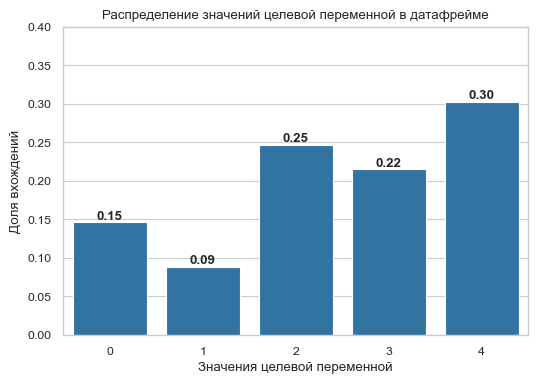

In [33]:
# Визуализируем распределение значений в churn
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=target_values, x='age_category', y='Доля вхождений')

# Добавляем подписи внутри столбцов
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        fontweight='bold'
    )

plt.ylim(0, 0.4)
plt.title('Распределение значений целевой переменной в датафрейме')
plt.xlabel('Значения целевой переменной')
plt.show()



Видим, что существует ощутимый дисбаланс классов. Количество записей о группах людей старше 25 лет (категории 2,3,4) в относителных значениях может вдвое превышать кол-во записей для зумеров (категории 0,1).

### Анализ признаков

Выделим категориальные и числовые признаки, представленные в датафрейме.

In [34]:
# Список категориальных признаков
cat_features = X.select_dtypes(include=['object']).columns.to_list()
cat_features = sorted(cat_features)
print('Категориальные признаки:')
for i, feature in enumerate(cat_features, start=1):
    print(f'{i}: {feature}')
    
# Список числовых признаков
num_features = X.select_dtypes(include=['number']).columns.to_list()
num_features = sorted(num_features)
print('\n', 'Числовые признаки:')
for i, feature in enumerate(num_features, start=1):
    print(f'{i}: {feature}')

Категориальные признаки:
1: ads_activity
2: cloud_usage
3: primary_device
4: surf_depth

 Числовые признаки:
1: afternoon
2: amount_sessions
3: category_01
4: category_02
5: category_03
6: category_04
7: category_05
8: category_06
9: category_07
10: category_08
11: category_09
12: category_10
13: category_11
14: category_12
15: category_13
16: category_14
17: category_15
18: category_16
19: category_17
20: category_18
21: category_19
22: category_20
23: evening
24: morning
25: night


Оценим количество пропусков в признаках, для этого посчитаем количество пропусков в каждом из столбцов.

In [35]:
# Создадим функцию для отрображения количества пропусков в абсолютных и относительных значениях
def show_missing_stats(my_df):
    # Датафрейм с кол-вом пропусков по каждому столбцу
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': my_df.isnull().sum(),
        'Доля пропусков': my_df.isnull().mean()
    })
    missing_stats = missing_stats.loc[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    missing_stats = missing_stats.sort_values(by='Кол-во пропусков', ascending=False)
    
    # Форматируем при выводе через Styler
    return (missing_stats.style
            .format({'Доля пропусков': '{:.2%}'}))

# Выполняем функцию
show_missing_stats(X)

,Кол-во пропусков,Доля пропусков
ads_activity,233,4.00%
primary_device,157,2.69%
cloud_usage,146,2.51%
surf_depth,111,1.91%


Пропуски присутствуюют только в категориальных признаках. Отметим возможные стратегии заполенния пропусков:
- пропуски в `ads_activity` могут быть обусловлены тем, что пользователь никогда не взааимодействовал с рекламными банерами, однако сказать об этом наверняка нельзя. Ввиду этого целесообразно заполнить пропуск значением заглушкой `unknown`;
- пропуски в `primary_device` могут быть обусловлены тем, что сервис сбора данных не смог установить информацию о типе основного устройства пользователя. Ввиду этого целесообразно заполнить пропуск значением заглушкой `unknown`;
- пропуски в `cloud_usage` и `surf_depth` также нельзя отнести к какой-то определенной категории, ввиду чего из также будем заполнять заглушкой `unknown`

Другими слова мы выделеним пропуски в категориальных данных в отдельную категорию-заглушку `unknown`, что позволит моделям машинного обучения выявить закономерности в самом факте отсутствия этой активности. Это может служить хорошим индикатором для классификации определенных возрастных групп.

#### Анализ категориальных признаков

Теперь оценим количество уникальных значений в каждом категориальном признаке. Это необходимо для выбора рационального способа кодирования на последующих этапах предобработки.

In [36]:
def count_unique_cat_features(X):
    cat_features = X.select_dtypes(include=['object']).columns.to_list()
    df_unique_cat = X[cat_features].nunique().sort_values()
    return df_unique_cat

print('Кол-во уникальных значений в каждом категориальном признаке:')
unique_cat_counter = count_unique_cat_features(X)
print(unique_cat_counter)

Кол-во уникальных значений в каждом категориальном признаке:
cloud_usage       2
surf_depth        3
primary_device    4
ads_activity      5
dtype: int64


Видим, кол-во уникальных значений каждого категориального признака не превышает 10 шт., а значит опитимально будет их кодирование с помощью `OneHotEncoder`.

Визуализируем распределения категориальных столбцов.

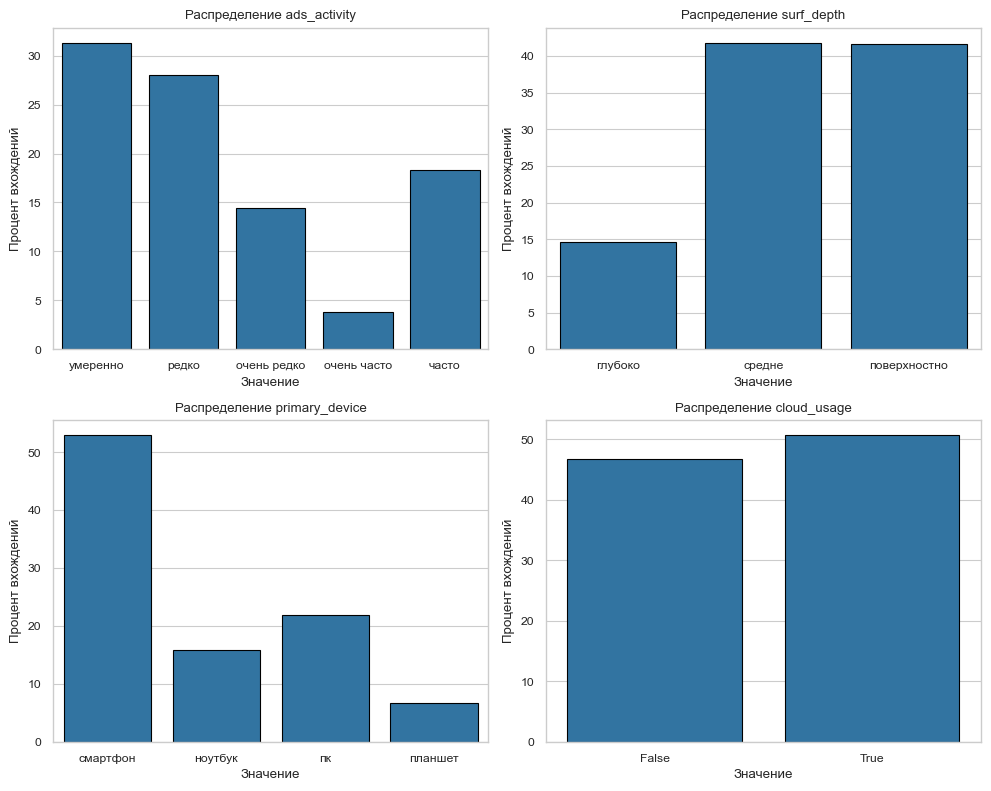

In [37]:
# Функция для построения столбчатых диаграмм по датафрейму
def show_bar_plots(my_df):
    # Записываем названия категориальных столбцов
    cols = my_df.select_dtypes(include=['object']).columns.to_list()

    # Рассчитываем размер сетки (2 столбца на график)
    n_cols = 2
    n_rows = (len(cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten() if len(cols) > 1 else [axes]

    # Строим диаграммы
    for i, col in enumerate(cols):
        sns.countplot(data=my_df, x=col, ax=axes[i], edgecolor='black', stat="percent")
        axes[i].set_title(f'Распределение {col}')
        axes[i].set_xlabel('Значение')
        axes[i].set_ylabel('Процент вхождений')

    # Скрываем лишние оси
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# Выводим гистограммы
show_bar_plots(X)

Отметим следующие ключевые моменты:
- Основным устройством с которого большинство людей взаимодействует в сети является смартфон;
- Кол-во пользователей, использующих и неиспользующих облачные сервисы примерно одинаково;
- В основном пользователи не заходят в "глубину" сайта
- Большинство пользователей умеренно кликает на рекламные банеры. 

#### Анализ числовых признаков

Изучим значения в числовых столбцах датасета. Для этого выведем описательные статистические данные о значениях в этих столбцах.

In [38]:
num_features_describe = X[num_features].describe(percentiles=[0.25, 0.5, 0.75, 0.99]).T

num_features_describe.style.format('{:.2f}')

,count,mean,std,min,25%,50%,75%,99%,max
afternoon,5826.00,0.36,0.05,0.22,0.34,0.37,0.40,0.47,0.53
amount_sessions,5826.00,180.23,75.19,100.00,124.00,167.00,213.00,438.75,839.00
category_01,5826.00,0.05,0.03,0.00,0.03,0.05,0.07,0.13,0.18
category_02,5826.00,0.04,0.03,0.00,0.02,0.04,0.06,0.12,0.18
category_03,5826.00,0.07,0.05,0.00,0.02,0.06,0.10,0.20,0.26
category_04,5826.00,0.05,0.03,0.00,0.03,0.05,0.07,0.13,0.19
category_05,5826.00,0.06,0.03,0.00,0.04,0.06,0.08,0.13,0.17
category_06,5826.00,0.05,0.03,0.00,0.03,0.05,0.07,0.13,0.17
category_07,5826.00,0.05,0.03,0.00,0.03,0.05,0.07,0.13,0.17
category_08,5826.00,0.05,0.03,0.00,0.03,0.05,0.07,0.13,0.19


Отметим следующие моменты:
 - Признак `amount_sessions` измеряется сотнями (от 100 до 839). Все остальные признаки (категории и время суток) - это доли, их значения лежат в диапазоне от 0 до ~0.53.
 - Минимальное значение `amount_sessions` равно 100, т.е. каждый человек из выборки совершил как минимум 100 сессий.
 - `afternoon` и `evening` - самые активные часы. В среднем на них приходится по 36% активности (в сумме 72%).
 - Категории сайтов распределены довольно равномерно, в среднем каждая занимает 4-7% активности пользователя.

Визуализируем распределения в числовых столбцах.

In [39]:
# Функция для отображения гистограммы и диаграммы рассеяния
def show_numeric_hists_and_box(my_df, cols):

    n_vars = len(cols)
    n_cols = 2
    n_rows = (n_vars + n_cols - 1) // n_cols

    # Создаем фигуру (гистограмма + боксплот)
    fig, axes = plt.subplots(
        nrows=n_rows * 2, 
        ncols=n_cols, 
        figsize=(6 * n_cols, 5 * n_rows),
        gridspec_kw={"height_ratios": [0.8, 0.2] * n_rows},
        sharex=False
    )

    # Превращаем в плоский список для удобства итерации
    axes = axes.flatten() if n_vars > 1 else axes

    for i, col in enumerate(cols):
        # Вычисляем индексы для пары графиков
        idx_hist = (i // n_cols) * (n_cols * 2) + (i % n_cols)
        idx_box = idx_hist + n_cols
        
        ax_hist = axes[idx_hist]
        ax_box = axes[idx_box]

        mean_val = my_df[col].mean()
        median_val = my_df[col].median()
        p99 = my_df[col].quantile(0.99)

        # Строим гистограмму
        sns.histplot(data=my_df, x=col, ax=ax_hist, bins=30, edgecolor='black', kde=False)
        ax_hist.axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Медиана: {median_val:.1f}')
        ax_hist.axvline(mean_val, color='orange', linestyle='--', linewidth=1.5, label=f'Среднее: {mean_val:.1f}')
        ax_hist.axvline(p99, color='red', linestyle='--', linewidth=1.5, label=f'99-й процентиль: {p99:.1f}')
        
        ax_hist.set_title(f'Распределение {col}')
        ax_hist.set_ylabel('Частота')
        ax_hist.legend()

        # Строим диаграмму размаха
        sns.boxplot(data=my_df, x=col, ax=ax_box, fliersize=3)
        ax_box.axvline(mean_val, color='orange', linestyle='--', linewidth=1.5)
        ax_box.axvline(p99, color='red', linestyle='--', linewidth=1.5)
        
        # Синхронизируем оси X
        ax_box.set_xlim(ax_hist.get_xlim())
        ax_box.set_xlabel(col)

    # Скрываем неиспользуемые ячейки
    for j in range(n_vars, n_rows * n_cols):
        idx_empty_hist = (j // n_cols) * (n_cols * 2) + (j % n_cols)
        idx_empty_box = idx_empty_hist + n_cols
        axes[idx_empty_hist].set_visible(False)
        axes[idx_empty_box].set_visible(False)

    plt.tight_layout()
    plt.show()

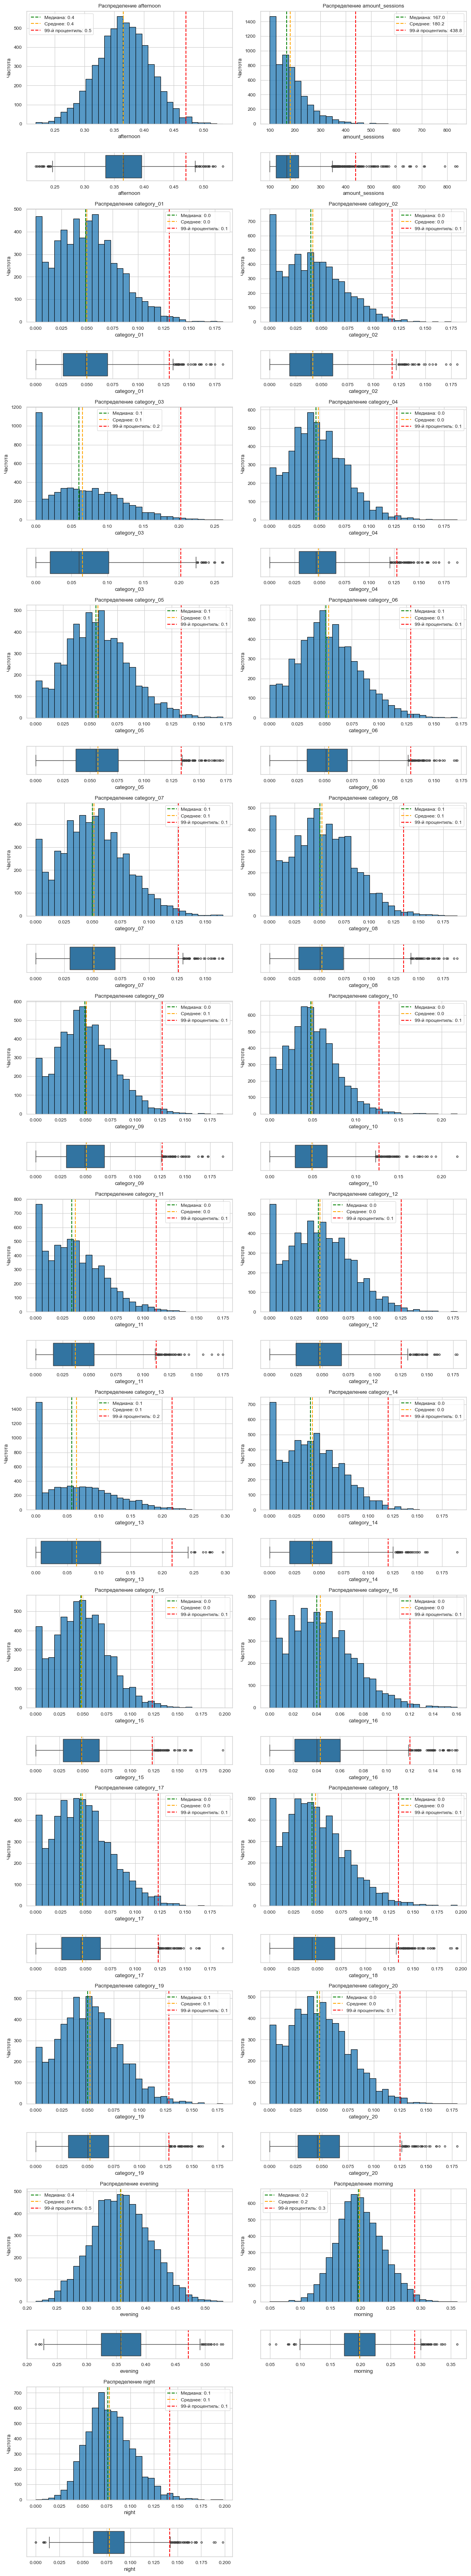

In [40]:
# вызов функции для числовых признаков 
show_numeric_hists_and_box(X, num_features)

**Отметим ключевые моменты:**
- Временные признаки (`morning`, `afternoon`, `evening`, `night`) имеют распределения близки к нормальному. Средние и медианы практически совпадают. Выбросов мало и они не критичные.

- Общая активность (`amount_sessions`) имеет сильную правосторонную асимметрию. Подавляющее большинство пользователей проявляют умеренную активность (медиана около 167 сессий), но есть длинный "хвост" из активных пользователей (доходящий до 800+ сессий). Значительное количество выбросов справа.

- Категории сайтов (`category_01` - `category_20`) имеют правостороннюю асимметрию и сильную концентрацию значений возле нуля. Большинство пользователей вообще не интересуется большинством категорий (концентрация на нуле). Но в каждой категории есть своя аудитория, которая образует правый хвост выбросов.

**Промежуточный вывод по результатам EDA**:
- Cуществует ощутимый дисбаланс классов в целевой переменной. Количество записей о группах людей старше 25 лет (категории 2,3,4) в относителных значениях превышает кол-во записей для зумеров (категории 0,1). При разбиении данных на фолды при кросс-валидации необходимо пользоваться стратификацией.
- Кол-во уникальных значений каждого категориального признака не превышает 10 шт., а значит опитимально будет их кодирование с помощью `OneHotEncoder`.
- Признак `amount_sessions` измеряется сотнями (от 100 до 839). Все остальные признаки (категории и время суток) - это доли, их значения лежат в диапазоне от 0 до ~0.53. Ввиду этого на этапе предобработки требуется масштабирование признаков с помощью `StandartScaler`
- `afternoon` и `evening` - самые активные часы. В среднем на них приходится по 36% активности (в сумме 72%).
- Категории сайтов распределены довольно равномерно, в среднем каждая занимает 4-7% активности пользователя.
- Временные признаки (`morning`, `afternoon`, `evening`, `night`) имеют распределения близки к нормальному.
- Признаки `category_01` - `category_20` имеют выбросы, однако в общем масштабе данных они не критичны т.к. выбросы превышают медиану не более чем на порядок.

[Назад к оглавлению](#toc)

<a id="предобработка-данных"></a>
## Предобработка данных

Разделим данные в пропорции 80% для обучения и валидации модели, а 20% оставим для теста.

In [41]:
# Разеделим данные для теста и валидации/обучения
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

Убедимся в правильности разделения на выборки и выведем их размеры.

In [42]:
# Проверка размеров
print(f"Общее количество образцов: {len(X)}")
print("-" * 80)
print("Набор данных                            | Размер    | Цель")
print("-" * 80)
print(f"Тренировочный/валидационный (Train/Val) | {len(X_train_val)}      | Обучение базовой модели")
print(f"Тестовый (Test)                         | {len(X_test)}      | Финальная оценка")
print("-" * 80)
print(f"Сумма: {len(X_train_val) + len(X_test)}")

Общее количество образцов: 5826
--------------------------------------------------------------------------------
Набор данных                            | Размер    | Цель
--------------------------------------------------------------------------------
Тренировочный/валидационный (Train/Val) | 4660      | Обучение базовой модели
Тестовый (Test)                         | 1166      | Финальная оценка
--------------------------------------------------------------------------------
Сумма: 5826


### Создание пайплайна для предобработки данных

Опишем стратегию предобработки данных:

**Для числовых признаков:** Масштабированих данные с помощью `StandardScaler`.

**Для категориальных признаков:**
- обработка булевых значений (перевод их к категориальным)
- Заполнение пропусков значением-заглушкой `unknown`
- кодирование c помощью `One-Hot Encoding`.

In [43]:
print('Категориальные признаки cat_features:\n', cat_features)
print('\nЧисловые признаки num_features:\n', num_features)

Категориальные признаки cat_features:
 ['ads_activity', 'cloud_usage', 'primary_device', 'surf_depth']

Числовые признаки num_features:
 ['afternoon', 'amount_sessions', 'category_01', 'category_02', 'category_03', 'category_04', 'category_05', 'category_06', 'category_07', 'category_08', 'category_09', 'category_10', 'category_11', 'category_12', 'category_13', 'category_14', 'category_15', 'category_16', 'category_17', 'category_18', 'category_19', 'category_20', 'evening', 'morning', 'night']


In [44]:
# Функция для замены булевых выражений категориальными
def replace_bools(X):
    return X.replace({True: 'yes', False: 'no'})

# Оборачиваем в трансформер
bool_transformer = FunctionTransformer(replace_bools, feature_names_out='one-to-one')
    
# Пайплайн для категориальных признаков
cat_pipeline = Pipeline([
    ('bool_transformer', bool_transformer),
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Пайплайн для числовых признаков
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Предобработка
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, cat_features),
        ('num', num_pipeline, num_features)
    ], remainder='drop'
).set_output(transform='pandas')

# Преобразуем признаки
X_train_val_transformed = preprocessor.fit_transform(X_train_val)

In [45]:
# Выведем информацию о преобразованных признаках
X_train_val_transformed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4660 entries, 1104 to 2893
Data columns (total 43 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cat__ads_activity_unknown      4660 non-null   float64
 1   cat__ads_activity_очень редко  4660 non-null   float64
 2   cat__ads_activity_очень часто  4660 non-null   float64
 3   cat__ads_activity_редко        4660 non-null   float64
 4   cat__ads_activity_умеренно     4660 non-null   float64
 5   cat__ads_activity_часто        4660 non-null   float64
 6   cat__cloud_usage_no            4660 non-null   float64
 7   cat__cloud_usage_unknown       4660 non-null   float64
 8   cat__cloud_usage_yes           4660 non-null   float64
 9   cat__primary_device_unknown    4660 non-null   float64
 10  cat__primary_device_ноутбук    4660 non-null   float64
 11  cat__primary_device_пк         4660 non-null   float64
 12  cat__primary_device_планшет    4660 non-null   flo

**Промежуточный вывод**:
- в категориальных признаках предварительно было проведено:
    - предварительная обработка булевых значений (перевод их к категориальным);
    - заполнение прпусков значением-заглушкой `unknown`;
    - кодирование данных с помощью `OneHotEncoder`
- в числовых признаках значения были отмасштабированы с помощью `StandardScaler`

[Назад к оглавлению](#toc)

<a id="обучение-и-оценка-базовой-модели"></a>
## Обучение и оценка базовой модели

Обучим базовую версию модели `DummyClassifier`, чтобы обозначить самый простой базовый уровень работы модели.

In [46]:
# Настраиваем кросс-валидацию
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Выписываем метрики
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

# Создаем DummyClassifier
dummy_model = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)

# Создадим пайплайн для DummyClassifier
dummy_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('classifier', dummy_model)
])

'''Проведем кросс валидацию'''
print("--- Запуск кросс-валидации ---")
start_time = time()
print(f"Оценка модели: DummyClassifier...", end=' ')

# Кросс-валидация
cv_res_dummy = cross_validate(
    estimator=dummy_pipeline,
    X=X_train_val,
    y=y_train_val,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    error_score='raise')

end_time = time()
print(f"Готово за {end_time - start_time:.2f} сек.")

# Записываем результаты кросс-валидации
results_dummy = pd.DataFrame(cv_res_dummy)

# Запишем средние значения метрик и стандартные отклонения
summary_results_dummy = pd.DataFrame({'mean': results_dummy.mean(),
                                      'std': results_dummy.std()})

# Выведем средние значения метрик и стандартные отклонения
summary_results_dummy.style.format('{:.3f}')


--- Запуск кросс-валидации ---
Оценка модели: DummyClassifier... Готово за 2.55 сек.


,mean,std
fit_time,0.027,0.001
score_time,0.021,0.003
test_accuracy,0.303,0.001
test_f1_macro,0.093,0.000
test_precision_macro,0.061,0.000
test_recall_macro,0.200,0.000


**Промежуточный вывод**: обучена базовая модель, которая дает предсказания на основе наиболее распространенного класса. Для такой модели ключевая метрика качества `F1-marco` составляет 0.093, что будет являтся отправной точкой при оценке остальных моделей.

[Назад к оглавлению](#toc)

<a id="создание-и-отбор-признаков"></a>
## Создание и отбор признаков

### Корреляция признаков 

Рассмотрим корреляцию признаков для выявляения наиболее скоррелированных.

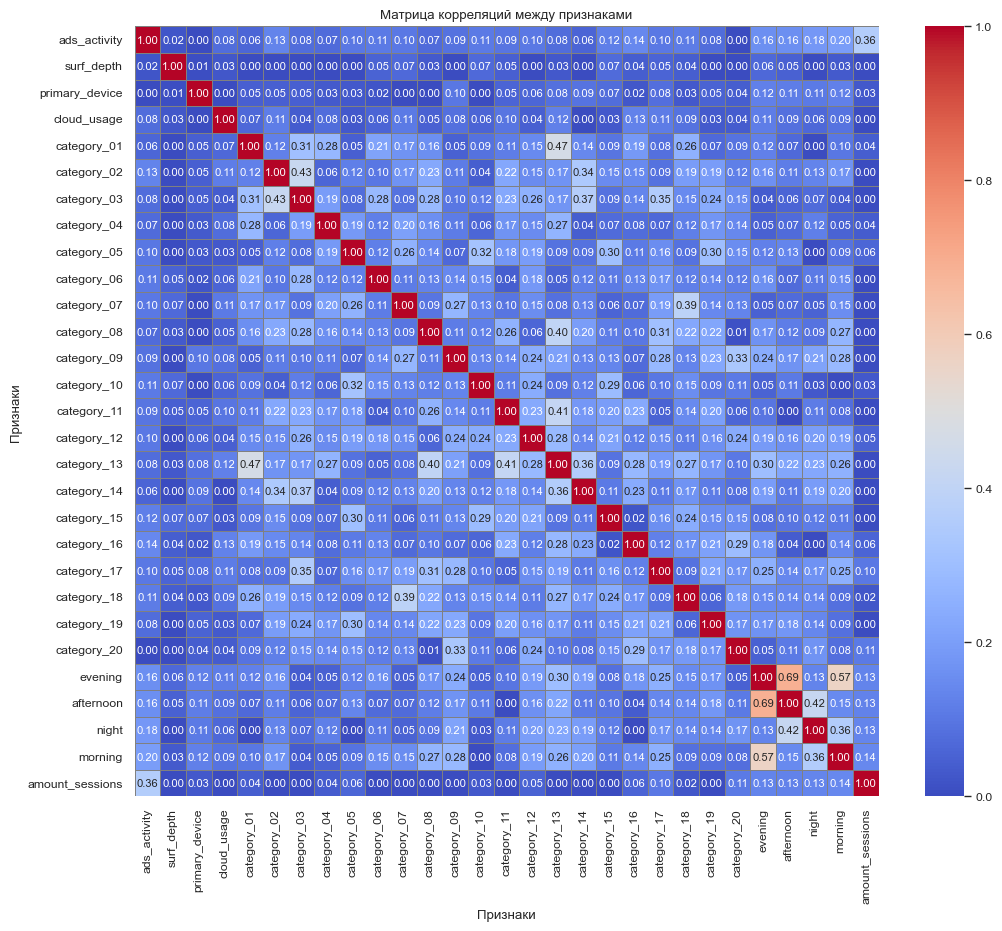

In [47]:
# Объединяем признаки и целевую переменную
df_train_val= X_train_val.join(y_train_val)

# Создаем матрицу корреляции
corr_matrix = df_train_val.phik_matrix(interval_cols=num_features)

# Оставляем только признаки
feature_corr_matrix = corr_matrix[corr_matrix.index != 'age_category']
feature_corr_matrix = feature_corr_matrix.drop(columns=['age_category'])

# Визуализируем матрицу корреляции
plt.figure(figsize=(12,10))

sns.heatmap(
    feature_corr_matrix, 
    annot=True,    
    annot_kws={"size": 8},
    cmap='coolwarm',
    fmt=".2f",     
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor='grey'
)

plt.title("Матрица корреляций между признаками")
plt.xlabel('Признаки')
plt.ylabel('Признаки')
plt.show()

Из тепловой карты видно, что высокоскореллированные признаки, для которых phi_k > 0.8 отсутствуют. Виду чего на данном этапе считается целесообразным оставить все признаки для обучения модели.

### Корреляция признаков с целевой переменной

Рассчитаем корреляцию между признаками и целевой переменной.

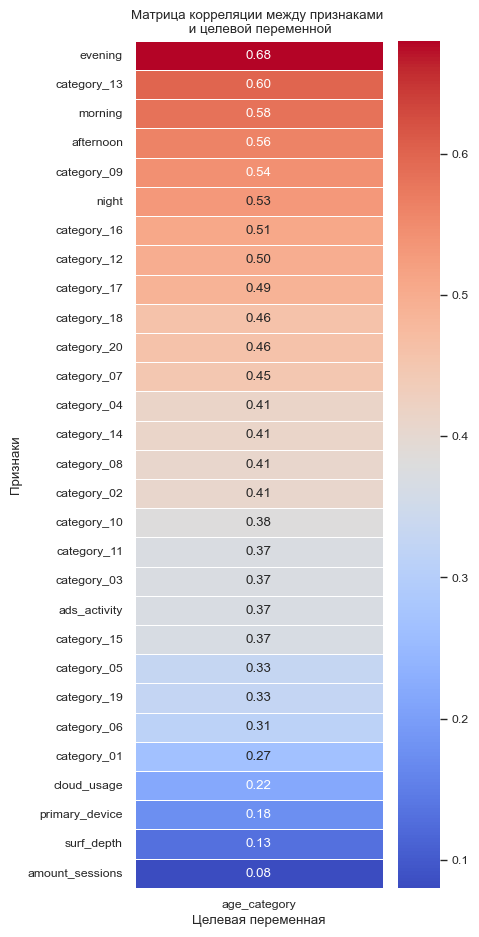

In [48]:
# Оставляем только столбец с целевой переменной
corr_matrix_target = corr_matrix.loc[corr_matrix.index != 'age_category'][['age_category']].sort_values(by='age_category', ascending=False)

# Визуализируем результат с помощью тепловой карты
plt.figure(figsize=(4, 11))
sns.heatmap(data=corr_matrix_target, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Матрица корреляции между признаками \n и целевой переменной")
plt.xlabel('Целевая переменная')
plt.ylabel('Признаки')
plt.show()

По данным, представленным на тепловой карте можно отметить:
- признаки, описывающие время посещения сайта значительно коррелируют с целевой переменной. Для таких признаков коэффициент корреляции phi_k лежит в диапозоне от 0.53 (`night`) до 0.68 (`evening`).
- доля от общего количества сессий, проведенная на анонимизицированной категории сайта также в значительной степени коррелируют с целевой переменной. Для таких признаков phi_k лежит в диапозоне от 0.27 (`category_1`) до 0.60 (`category_13`).
- категориальные признаки `cloud_usage`, `primary_device`, `surf_depth` обладают слабой корреляцией с целевой переменной.
- количество сессий `amount_sessions` почти никак не влияет на возраст.

Отберем признаки, для которых коэффициент корреляции составляет более 0.1 с целевой переменной признаков. Остальные признаки имеют крайне слабую коореляцию с целевой переменной, ввиду чего будут только зашумлять модель и не давать значительного вклада в результат предсказания.

In [49]:
# Отберем признаки, для которых phi_k > 0.1
best_features_phi_k =corr_matrix_target.loc[corr_matrix_target['age_category'] > 0.1].index.to_list()

# Выведем выбранные признаки
print('Лучшие признаки для обучения модели с точки зрения корреляции с таргетом:')
for i, feature in enumerate(best_features_phi_k, start=1):
    print(f"{i}:{feature}")

Лучшие признаки для обучения модели с точки зрения корреляции с таргетом:
1:evening
2:category_13
3:morning
4:afternoon
5:category_09
6:night
7:category_16
8:category_12
9:category_17
10:category_18
11:category_20
12:category_07
13:category_04
14:category_14
15:category_08
16:category_02
17:category_10
18:category_11
19:category_03
20:ads_activity
21:category_15
22:category_05
23:category_19
24:category_06
25:category_01
26:cloud_usage
27:primary_device
28:surf_depth


### Метод-обёртки

Применим метод прямого отбора признаков (FFS) т.к. оптимальное число параметров для модели на данном этапе определить невозможно.

In [50]:
# Выбираем классификатор для поиска
clf = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs"
) 

# Настройка селектора
sfs = SequentialFeatureSelector(clf,
                                n_features_to_select='auto',
                                direction='forward',
                                cv=5,
                                scoring='f1_macro',
                                n_jobs = -1)

# Применяем отбор к данным
sfs.fit(X_train_val_transformed, y_train_val)

# Получаем отобранные признаки
best_features_ffs = X_train_val_transformed.columns[sfs.get_support()].tolist()
print(f'\nВыбранные признаки SFS (Forward):')
for i, feature in enumerate(best_features_ffs, start=1):
    print(f"{i}:{feature}")


Выбранные признаки SFS (Forward):
1:cat__cloud_usage_no
2:cat__primary_device_ноутбук
3:cat__primary_device_пк
4:num__afternoon
5:num__category_02
6:num__category_05
7:num__category_06
8:num__category_07
9:num__category_08
10:num__category_09
11:num__category_10
12:num__category_11
13:num__category_12
14:num__category_13
15:num__category_15
16:num__category_16
17:num__category_17
18:num__category_18
19:num__category_20
20:num__evening
21:num__night


Из результатов работы метода-обертки `SequentialFeatureSelector` видим, что он отобрал высокоскоррелированные с целевой переменной признаки, но при этом убрал некоторые ненужные категории (`cat__cloud_usage_no`, `cat__primary_device_ноутбук`, `cat__primary_device_пк`) для максимизации целевой метрики `F1-marco`. В дальнейшем модели будем обучать на оптимальном наборе признаков, полученным из SFS. Для того, чтобы отобрать необходимые признаки и при этом не увеличивать кратно время обучения путем внеднерия SFS в финальный пайалайн решено написать отдельный класс `FeatureSelector`, который будет отбирать признаки полученные из SFS вне пайплайна.

In [51]:
class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_names):
        self.feature_names = feature_names
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X[self.feature_names]
    
    def get_feature_names_out(self, input_features=None):
        return self.feature_names    

### Подготовка моделей

Для решения задачи многоклассовой классификации будем использовать следующие подходы:
- решение задачи One-vs-Rest с помощью класса `OneVsRestClassifier`, в качестве бинарного классификатора будем использовать логистическую регрессию и SVM;
- решение задачи One-vs-One с помощью класса `OneVsOneClassifier`, в качестве бинарного классификатора будем использовать логистическую регрессию и SVM;
- использование логистической регрессии для многоклассовой задачи.

In [52]:
''' Создание бинарных классификаторов '''

# Создаём бинарный классификатор логистической регрессии
base_model_logreg = LogisticRegression(random_state=RANDOM_SEED)
# Создаём бинарный классификатор SVM
base_model_svm = SVC(kernel='linear', random_state=RANDOM_SEED)

''' Создание моделей для мультиклассовой задачи '''

# Оборачиваем logreg в OneVsRestClassifier
ovr_logreg = OneVsRestClassifier(estimator=base_model_logreg)
# Оборачиваем SVM в OneVsRestClassifier
ovr_svm = OneVsRestClassifier(estimator=base_model_svm)

# Оборачиваем logreg в OneVsRestClassifier
ovo_logreg = OneVsOneClassifier(estimator=base_model_logreg)
# Оборачиваем SVM в OneVsRestClassifier
ovo_svm = OneVsOneClassifier(estimator=base_model_svm)

# Модель мульклассовой логистической регрессии
multi_logreg = LogisticRegression(multi_class="multinomial",
                                  solver="lbfgs",
                                  random_state=RANDOM_SEED)

''' Создание пайплайнов '''

pipelines = {
    "OneVsRestClassifier_LogReg": Pipeline(steps=[
        ('prep', preprocessor),
        ('selector', FeatureSelector(best_features_ffs)),
        ('classifier', ovr_logreg)
    ]),
    
    "OneVsRestClassifier_SVM": Pipeline(steps=[
        ('prep', preprocessor),
        ('selector', FeatureSelector(best_features_ffs)),
        ('classifier', ovr_svm)
    ]),
    
    "OneVsOneClassifier_LogReg": Pipeline(steps=[
        ('prep', preprocessor),
        ('selector', FeatureSelector(best_features_ffs)),
        ('classifier', ovo_logreg)
    ]),
    
    "OneVsOneClassifier_SVM": Pipeline(steps=[
        ('prep', preprocessor),
        ('selector', FeatureSelector(best_features_ffs)),
        ('classifier', ovo_svm)
    ]),
    
    "Multinomial_LogReg": Pipeline(steps=[
        ('prep', preprocessor),
        ('selector', FeatureSelector(best_features_ffs)),
        ('classifier', multi_logreg)
    ])
}

Проведем кросс валидацию для указанных моделей без перебора оптимальных гиперпараметров.

In [53]:
results_list = []

print("--- Запуск кросс-валидации ---")
for name, pipe in pipelines.items():
    start_time = time()
    print(f"Оценка модели: {name:}...", end=' ')
    
    cv_res = cross_validate(
        estimator=pipe,
        X=X_train_val,
        y=y_train_val,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        error_score='raise')
    
        # Усреднённые метрики
    new_row = {
        'model': name,
        **{f'{m}_mean': cv_res[f'test_{m}'].mean() for m in scoring}
    }
    
    results_list.append(new_row)
    end_time = time()
    print(f"Готово за {end_time - start_time:.2f} сек.")

results_df = pd.DataFrame(results_list)

results_df

--- Запуск кросс-валидации ---
Оценка модели: OneVsRestClassifier_LogReg... Готово за 0.37 сек.
Оценка модели: OneVsRestClassifier_SVM... Готово за 3.24 сек.
Оценка модели: OneVsOneClassifier_LogReg... Готово за 0.39 сек.
Оценка модели: OneVsOneClassifier_SVM... Готово за 1.12 сек.
Оценка модели: Multinomial_LogReg... Готово за 0.25 сек.


,model,accuracy_mean,f1_macro_mean,precision_macro_mean,recall_macro_mean
0,OneVsRestClassifier_LogReg,0.823,0.777,0.806,0.767
1,OneVsRestClassifier_SVM,0.798,0.724,0.738,0.725
2,OneVsOneClassifier_LogReg,0.838,0.806,0.812,0.801
3,OneVsOneClassifier_SVM,0.834,0.801,0.807,0.797
4,Multinomial_LogReg,0.836,0.804,0.813,0.799


**Промежуточные выводы**:
- все модели, кроме `OneVsRestClassifier_SVM` из коробки показывают удовлетворительные для заказчика значения метрики качества `F1-marco` более 0.75. Низкое по сравнению с остальными моделями качетсво ключевой метрики `OneVsRestClassifier_SVM` обусловлено тем, что стратегия OvR создает искусственный дисбаланс классов, ввиду чего для минимизации ошибки разделяющая гиперплоскость располагается ближе к меньшему классу для минимизации ошибки и бинарный классификатор начинает предсказывать почти всё как класс 0.
- Наилучшей моделью по ключевой метрике является `OneVsOneClassifier_LogReg` и незначительно превышает показатели `Multinomial_LogReg`. При этом `OneVsOneClassifier_LogReg` обучает 10 отдельных моделей т.е. занимает больше памяти и обучается чуть дольше, в то время как `Multinomial_LogReg` обучает одну модель и работает быстрее. По этой причине в текущей момент лучшей моделью с точки зрения внедрения в продакшн является именно `Multinomial_LogReg`.

[Назад к оглавлению](#toc)

<a id="подбор-гиперпараметров-моделей"></a>
## Подбор гиперпараметров моделей

Создадим параметрическую сетку для определения наилучших гиперпараметров для созданных моделей.

In [54]:
''' Создаем словарь с сетками гиперпараметров для каждой модели '''

param_grids = {
    "OneVsRestClassifier_LogReg": {
        'classifier__estimator__C': [0, 0.1, 1, 10, 100],
        'classifier__estimator__class_weight': ['balanced', None]
    },
    
    "OneVsRestClassifier_SVM": [
    {
        'classifier__estimator__kernel': ['linear'],
        'classifier__estimator__C': [0.1, 1, 10],
    },
        
    {
        'classifier__estimator__kernel': ['rbf'],
        'classifier__estimator__C': [0.1, 1, 10],
        'classifier__estimator__gamma': ['scale', 'auto', 0.1, 1]
    }
],
    
    "OneVsOneClassifier_LogReg": {
        'classifier__estimator__C': [0.1, 1, 10, 100],
        'classifier__estimator__class_weight': ['balanced', None]
    },
    
    "OneVsOneClassifier_SVM": {
        'classifier__estimator__C': [0.1, 1, 10]
    },
    
    "Multinomial_LogReg": {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__class_weight': ['balanced', None]
    }
}

# Словарь для сохранения лучших моделей
best_models = {}
grid_results_list = []

''' Перебор гиперпараметров с помощью Grid Search '''

print("--- Запуск Grid Search ---")
for name, pipe in pipelines.items():
    start_time = time()
    print(f"Настройка параметров для: {name}...")
    
    # Достаем нужную сетку параметров
    current_param_grid = param_grids[name]
    
    # Инициализируем GridSearchCV
    grid_search = GridSearchCV(
        estimator=pipe,
        param_grid=current_param_grid,
        scoring=scoring,
        refit='f1_macro',
        cv=cv,
        n_jobs=-1
    )
    
    # Обучаем 
    grid_search.fit(X_train_val, y_train_val)
    
    # Сохраняем лучшую модель в словарь
    best_models[name] = grid_search.best_estimator_
    
    # Записываем результаты в таблицу
    results_df = pd.DataFrame(grid_search.cv_results_)
    best_idx = grid_search.best_index_
    
    # Добавляем в список метрики
    grid_results_list.append({
            'model': name,
            'accuracy': results_df.loc[best_idx, 'mean_test_accuracy'],
            'f1_macro': results_df.loc[best_idx, 'mean_test_f1_macro'],
            'precision': results_df.loc[best_idx, 'mean_test_precision_macro'],
            'recall': results_df.loc[best_idx, 'mean_test_recall_macro'],
            'best_params': grid_search.best_params_
        })
        
    end_time = time()
    print(f"Готово за {end_time - start_time:.2f} сек. Лучший F1: {grid_search.best_score_:.3f}")

# Выводим финальную таблицу
final_grid_results_df = pd.DataFrame(grid_results_list)
display(final_grid_results_df)

--- Запуск Grid Search ---
Настройка параметров для: OneVsRestClassifier_LogReg...
Готово за 2.13 сек. Лучший F1: 0.792
Настройка параметров для: OneVsRestClassifier_SVM...
Готово за 61.96 сек. Лучший F1: 0.873
Настройка параметров для: OneVsOneClassifier_LogReg...
Готово за 2.33 сек. Лучший F1: 0.810
Настройка параметров для: OneVsOneClassifier_SVM...
Готово за 5.63 сек. Лучший F1: 0.806
Настройка параметров для: Multinomial_LogReg...
Готово за 1.46 сек. Лучший F1: 0.804


,model,accuracy,f1_macro,precision,recall,best_params
0,OneVsRestClassifier_LogReg,0.823,0.792,0.790,0.795,"{'classifier__estimator__C': 0.1, 'classifier_..."
1,OneVsRestClassifier_SVM,0.901,0.873,0.889,0.864,"{'classifier__estimator__C': 1, 'classifier__e..."
2,OneVsOneClassifier_LogReg,0.843,0.810,0.821,0.803,"{'classifier__estimator__C': 0.1, 'classifier_..."
3,OneVsOneClassifier_SVM,0.839,0.806,0.813,0.802,{'classifier__estimator__C': 0.1}
4,Multinomial_LogReg,0.836,0.804,0.813,0.799,"{'classifier__C': 1, 'classifier__class_weight..."


In [55]:
# Запишем лучшую модель в отдельную переменную
best_model = best_models['OneVsRestClassifier_SVM']

# Выведем лучшие гиперпараметры для модели SVM
print('Гиперпараметры лучшей модели')
final_grid_results_df.loc[1,'best_params']

Гиперпараметры лучшей модели


{'classifier__estimator__C': 1,
 'classifier__estimator__gamma': 0.1,
 'classifier__estimator__kernel': 'rbf'}

**Промежуточный вывод**: лучшей моделью по ключевой метрике `F1-marco` является `OneVsRestClassifier_SVM` (`F1-marco` = 0.873). Указанная модель значительно превосходит остальные. Данный факт говорит о том, что граница между признаками нелинейна.

Модель `OneVsRestClassifier_SVM` с набором лучших гиперпараметров записана в переменную `best_model` и будет далее будет проверяться на тестовой выборке.

[Назад к оглавлению](#toc)

<a id="оценка-финальной-модели"></a>
## Оценка финальной модели

Финальная модель `OneVsRestClassifier_SVM` с набором лучших гиперпараметров записана в переменную `best_model` и уже обучена на всей тренировочной выборке (за счет параметра `refit='f1_macro'` в Grid Search).

Получим предсказания на тестовой выбоке и вычислим ключевую метрику `F1-marco` и вспомогательные `precision-marco`, `recall-marco`, `accuracy`.

In [56]:
# Получаем предсказания на тестовой выборке
y_pred = best_model.predict(X_test)

# Вычисляем метрики
p_macro = precision_score(y_test, y_pred, average='macro')
r_macro = recall_score(y_test, y_pred, average='macro')
f_macro = f1_score(y_test, y_pred, average='macro')
acc = accuracy_score(y_test, y_pred)

# Dыводим результаты
print("=== Финальные метрики на тестовой выборке (X_test) ===")
print(f"F1-marco:        {f_macro:.3f}")
print(f"precision-marco: {p_macro:.3f}")
print(f"recall-marco:    {r_macro:.3f}")
print(f"accuracy:        {acc:.3f}")

=== Финальные метрики на тестовой выборке (X_test) ===
F1-marco:        0.876
precision-marco: 0.883
recall-marco:    0.871
accuracy:        0.892


**Вывод**: Ключевая метрика `F1-marco` незначительно увеличилась на тестовых данных, что означает что переобучения остуствует и модель очень хорошо научилась обобщать данные и выявлять каждый класс. Также отмечается что метрики `precision-marco` и `recall-marco` каждая по отдельности имеют высокие значения, что говорит о том, что модель хорошо отделяет классы и достаточно точно (с вероятностью ~90% точно определяет классы).

Рассчитаем метрики по каждому классу в отдельности.

In [57]:
print(classification_report(y_test, y_pred, digits=2))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88       171
           1       0.84      0.76      0.80       103
           2       0.86      0.88      0.87       288
           3       0.91      0.89      0.90       251
           4       0.92      0.95      0.93       353

    accuracy                           0.89      1166
   macro avg       0.88      0.87      0.88      1166
weighted avg       0.89      0.89      0.89      1166



**Вывод**: Модель хорошо классифицирует даже малочисленные классы (класс 0, 1). Вероятность превильного определения любого класса превышает 75%.

Выведем матрицу ошибок и оценим статистику того, как часто элементы попадают в «чужие» классы и с какими классами это происходит чаще всего.

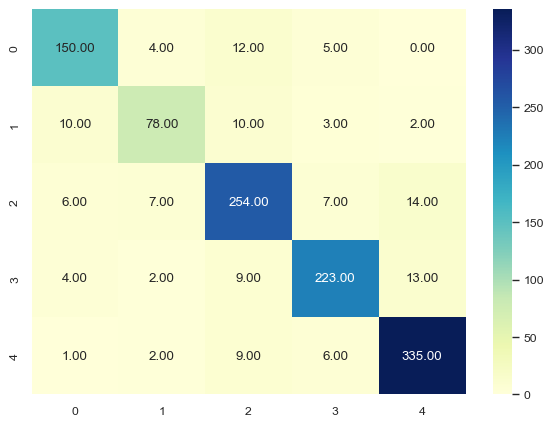

In [58]:
cm = confusion_matrix(y_test, y_pred, labels=[0,1,2,3,4])

# Зададим размер графика
fig, ax = plt.subplots(figsize=(7,5))

# Визуализируем матрицу на тепловой карте
ax = sns.heatmap(cm, annot=True, fmt='.2f', cmap='YlGnBu')
plt.show() 

**Вывод**: Диагональ тепловой карты темнее остальных областей — значит, модель хорошо различает классы.

#### Итоговый вывод по метрикам на тестовой выборке
- Ключевая метрика `F1-marco` составляет 0.876 т.е. выбраннвя модель удовлетворяет требованиям заказчика (`F1-marco` > 0.75) и рекомендуется к внедрению в продакшен.
- Модель хорошо справляется с задачей определения возраста пользователя и правильно классифицирует даже малочисленные классы

<a id="подготовка-артефактов-модели-для-внедрения"></a>
## Подготовка артефактов модели для внедрения

Для внедрения пайплайна в продакшен необходимо сохранить:
- вспомогательную функцию `load_data_from_csv`, которая читает CSV файлы из указанного пути и собирает их в словарь;
- функцию подготовки признаков `merge_tables`, которая принимает словарь датафреймов, агрегирует и собирает единую витрину.
- серилизованную модель `best_model`, выбранную по результатам исследования.
- код кастомного трансформера `FeatureSelector`

Сохраним лучшую модель.

In [59]:
# Создаем папку для артефактов
os.makedirs('deployment', exist_ok=True)

# Сохраним лучшую модель
joblib.dump(best_model, 'deployment/best_model.joblib')

['deployment/best_model.joblib']

Сохраним кастомный класс `FeatureSelector` для пайплайна

In [60]:
%%writefile custom_transformers.py

from sklearn.base import BaseEstimator, TransformerMixin

class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_names):
        self.feature_names = feature_names
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X[self.feature_names]
    
    def get_feature_names_out(self, input_features=None):
        return self.feature_names

Writing custom_transformers.py


Сохраним вспомогательную функцию `load_data_from_csv` и функцию подготовки признаков `merge_tables`.

In [61]:
%%writefile data_prep.py

import pandas as pd
import numpy as np

def load_data_from_csv():
    try:
        users_df = pd.read_csv('/datasets/ds_s13_users.csv')
        visits_df = pd.read_csv('/datasets/ds_s13_visits.csv')
        ads_activity_df = pd.read_csv('/datasets/ads_activity.csv')
        surf_depth_df = pd.read_csv('/datasets/surf_depth.csv')
        primary_device_df = pd.read_csv('/datasets/primary_device.csv')
        cloud_usage_df = pd.read_csv('/datasets/cloud_usage.csv')
    except:
        users_df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_users.csv')
        visits_df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_visits.csv')
        ads_activity_df = pd.read_csv('https://code.s3.yandex.net/datasets/ads_activity.csv')
        surf_depth_df = pd.read_csv('https://code.s3.yandex.net/datasets/surf_depth.csv')
        primary_device_df = pd.read_csv('https://code.s3.yandex.net/datasets/primary_device.csv')
        cloud_usage_df = pd.read_csv('https://code.s3.yandex.net/datasets/cloud_usage.csv')    

    df_dict = {
        'users_df': users_df,
        'visits_df': visits_df,
        'ads_activity_df': ads_activity_df,
        'surf_depth_df': surf_depth_df,
        'primary_device_df': primary_device_df,
        'cloud_usage_df': cloud_usage_df}
    
    return df_dict

def merge_tables(df_dict):
    
    '''Нормализуем данные в категориальных столбцах'''
    for df_name, df in df_dict.items():
        for col in df.select_dtypes(include=['object']).columns:
            df_dict[df_name][col] = df_dict[df_name][col].str.lower()
            df_dict[df_name][col] = df_dict[df_name][col].str.strip()
    
    '''Чистим от дубликатов'''
    for df_name, df in df_dict.items():
        df_dict[df_name] = df.drop_duplicates()
        
    '''Создаем агрегированные признаки количества сессий по категориям для каждого пользователя из visits_df'''
    session_per_category = pd.pivot_table(df_dict['visits_df'],
                                          index='user_id',
                                          columns='website_category',
                                          values='session_id',
                                          aggfunc='nunique',
                                          fill_value=0)

    # Убираем отображение имени колонок в pivot
    session_per_category.columns.name = None
    # Расчет количества сессий для каждого пользователя
    sesions_per_user = df_dict['visits_df'].groupby('user_id')['session_id'].nunique()
    # Перевод в относительные значения
    session_per_category = session_per_category.div(sesions_per_user, axis='index')
    # Сбрасываем индекс
    session_per_category = session_per_category.reset_index()
    
    '''Создаем агрегированные признаки количества сессий по временным категориям для каждого пользователя из visits_df'''
    session_per_daytime = pd.pivot_table(df_dict['visits_df'],
                                         index='user_id',
                                         columns='daytime',
                                         values='session_id',
                                         aggfunc='nunique',
                                         fill_value=0)

    # Убираем отображение имени колонок в pivot
    session_per_daytime.columns.name = None
    # Перевод в относительные значения
    session_per_daytime = session_per_daytime.div(sesions_per_user, axis='index')
    # Сбрасываем индекс
    session_per_daytime = session_per_daytime.reset_index()
    
    '''Создаем агрегированный признак кол-во сессий'''
    sesions_per_user = sesions_per_user.reset_index()
    sesions_per_user = sesions_per_user.rename(columns={'session_id': 'amount_sessions'})
    
    '''Объединяем все таблицы в одну'''
    result = (df_dict['users_df']
          .merge(df_dict['ads_activity_df'], on='user_id', how='left')
          .merge(df_dict['surf_depth_df'], on='user_id', how='left')
          .merge(df_dict['primary_device_df'], on='user_id', how='left')
          .merge(df_dict['cloud_usage_df'], on='user_id', how='left')
          .merge(session_per_category, on='user_id', how='left')
          .merge(session_per_daytime, on='user_id', how='left')
          .merge(sesions_per_user, on='user_id', how='left'))    
    
    '''Приводим названия к snake_case'''
    snake_names = []
    for col_name in result.columns:
        col_name = col_name.lower()
        if ' ' in col_name:
            col_name = col_name.replace(' ', '_')         
        snake_names.append(col_name)
        
    result.columns = snake_names
    # Меняем название столбцов на английские
    result = result.rename(columns={'вечер': 'evening', 'день': 'afternoon', 'ночь': 'night', 'утро': 'morning'})
    
    # Убираем user_id как бесполезный для обучения модели
    result = result.drop(columns=['user_id'])
    
    return result


Writing data_prep.py


Проверим работоспособность загруженной модели. Для этого загрузим сохранённые артефакты и сделаем предсказания.

In [62]:
# Загрузим модель из файла в переменную loaded_model
loaded_model = joblib.load('deployment/best_model.joblib')

# Берем первые 5 объектов из теста как пример новых данных
X_new = X_test.iloc[:5]
y_new_true = y_test.iloc[:5]

# Запоминаем предсказания
loaded_preds = loaded_model.predict(X_new)

# Оригинальные предсказания
original_preds = best_model.predict(X_new)

# Сравниваем результаты
comapare_preds = np.allclose(original_preds, loaded_preds)

if comapare_preds:
    print('Загрузка модели выполнена успешно!')


Загрузка модели выполнена успешно!


[Назад к оглавлению](#toc)

<a id="выводы-о-результатах-работы"></a>
## Выводы о результатах работы

**1. Общий обзор проделанной работы.**

В ходе исследования была построена модель машинного обучения, которая по данным о поведении анонимного пользователя в цифровой среде будет определяет его примерный возраст. По итогам исследования была выбрана наилучшая модель, ключевая метрика которой на тестовых данных составила 0.876. Такой показатель превышает требования заказчика ввиду чего модель рекомендуется к внедрению в продакшен.

**2. Главные выводы.**

- **Отбор признаков**:
    - Метод-обертки (Sequential Feature Selector) отобрал лучшие признаки для обучения модели. Даже базовые варианты моделей (без оптимальных гиперпараметров) показывали значения метрики F1 близкие к 0.75, а иногда и превышали его
    - Удалось снизить время выполнения отбора признаков за счет создания кастомного класса `FeatureSelector`, который сохранил результаты работы Sequential Feature Selector вне пайплайна.

- **Интерпретация наиболее важных признаков**: Ввиду того, что категории сайтов анонимизированны нельзя в полной мере интерпретировать их значение, однако можно сказать, что доля времени проведенная на том или ином сайте, а также время суток достаточно хорошо описывает возрастную группу пользователя. Почти все признаки с категориями сайтов и временем суток были задействованы при обучении модели
    
- **Лучшая модель**: Лучшей моделью по ключевой метрике `F1-marco` является `OneVsRestClassifier_SVM` (`F1-marco` = 0.873). Указанная модель значительно превосходит остальные. Данный факт говорит о том, что граница между признаками нелинейна.

- **Способность лучшей модели к классификации**: Модель очень хорошо научилась обобщать данные и выявлять каждый класс. Также отмечается что метрики `precision-marco` и `recall-marco` каждая по отдельности имеют высокие значения, что говорит о том, что модель хорошо отделяет классы и достаточно точно определяет классы.

- **Сохранение артефактов модели для внедрения**: Для внедрения пайплайна в продакшен были сохренены: функция для загрузки и чтения csv-файлов;  функция подготовки признаков, которая принимает словарь датафреймов, агрегирует и собирает единую витрину; серилизованная модель `best_model`, выбранная по результатам исследования; код кастомного трансформера `FeatureSelector`.

[Назад к оглавлению](#toc)